# Data Hierarchy: Physical → Statistical → Audio Processing Interpretation

## PHYSICAL DATA STRUCTURE

### Directory Hierarchy
```text
data/raw/
├── train.csv
├── train_soundscapes_labels.csv
├── taxonomy.csv
├── sample_submission.csv
├── recording_location.txt
│
├── train_audio/
│   ├── {species_id}/
│   │   ├── iNat{id}.ogg
│   │   ├── XC{id}.ogg
│   │   └── ...
│   └── {species_code}/
│       └── *.ogg
│
├── train_soundscapes/
│   └── *.ogg
│
└── test_soundscapes/
    └── *.ogg
```

### File Types & Formats

| File | Purpose | Structure / Format | Interpretation |
|---|---|---|---|
| `train.csv` | Primary metadata table | Tabular CSV | Contains sample-level metadata such as species labels, geographic coordinates, quality ratings, and filenames |
| `train_soundscapes_labels.csv` | Multi-label annotations | CSV with time-window labels | Maps soundscape windows to multiple active species |
| `taxonomy.csv` | Taxonomic hierarchy | CSV | Maps species into biological classes such as Aves, Amphibia, Insecta |
| `sample_submission.csv` | Competition inference format | CSV | Defines expected prediction schema |
| `recording_location.txt` | Recording site information | Text file | Useful for ecological/geographic priors |
| `*.ogg` | Audio recordings | OGG Vorbis compressed audio | Stores wildlife vocalizations with lossy compression optimized for storage efficiency |

---

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
import librosa
import soundfile as sf
from tqdm import tqdm

In [3]:
# Set paths
DATA_RAW = Path("/home/legionlinux/miniconda3/envs/torchenv/__INIT__/Kaggle/birdclef-2026/data/raw")
TRAIN_AUDIO_DIR = DATA_RAW / "train_audio"
TRAIN_SOUNDSCAPES_DIR = DATA_RAW / "train_soundscapes"
TEST_SOUNDSCAPES_DIR = DATA_RAW / "test_soundscapes"

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Load all files

In [4]:
train_df = pd.read_csv(DATA_RAW / "train.csv")
train_soundscapes_labels_df = pd.read_csv(DATA_RAW / "train_soundscapes_labels.csv")
taxonomy_df = pd.read_csv(DATA_RAW / "taxonomy.csv")
sample_submission_df = pd.read_csv(DATA_RAW / "sample_submission.csv")

# Section A: CSV Metadata Files Analysis

### `train.csv`

In [8]:
train_df.shape

(35549, 15)

In [9]:
train_df.columns

Index(['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude',
       'scientific_name', 'common_name', 'class_name', 'inat_taxon_id',
       'author', 'license', 'rating', 'url', 'filename', 'collection'],
      dtype='object')

In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35549 entries, 0 to 35548
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   primary_label     35549 non-null  object 
 1   secondary_labels  35549 non-null  object 
 2   type              35549 non-null  object 
 3   latitude          35549 non-null  float64
 4   longitude         35549 non-null  float64
 5   scientific_name   35549 non-null  object 
 6   common_name       35549 non-null  object 
 7   class_name        35549 non-null  object 
 8   inat_taxon_id     35549 non-null  int64  
 9   author            35549 non-null  object 
 10  license           35549 non-null  object 
 11  rating            35549 non-null  float64
 12  url               35549 non-null  object 
 13  filename          35549 non-null  object 
 14  collection        35549 non-null  object 
dtypes: float64(3), int64(1), object(11)
memory usage: 4.1+ MB


In [12]:
train_df.head()

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


In [13]:
train_df.tail()

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
35544,yeofly1,[],['call'],-6.7281,-76.4181,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,GABRIEL LEITE,by-nc-sa,4.0,https://xeno-canto.org/762473/download,yeofly1/XC762473.ogg,XC
35545,yeofly1,[],"['call', ' song']",-16.0538,-49.6040,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,JAYRSON ARAUJO DE OLIVEIRA,by-nc-sa,5.0,https://xeno-canto.org/818328/download,yeofly1/XC818328.ogg,XC
35546,yeofly1,[],['song'],5.9002,-74.8485,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,Jerome Fischer,by-nc-sa,4.0,https://xeno-canto.org/425545/download,yeofly1/XC425545.ogg,XC
35547,yeofly1,[],['song'],3.3821,-61.4464,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,GABRIEL LEITE,by-nc-sa,4.0,https://xeno-canto.org/456230/download,yeofly1/XC456230.ogg,XC
35548,yeofly1,[],['song'],-19.4144,-42.4151,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,Roney Souza,by-nc-sa,5.0,https://xeno-canto.org/298884/download,yeofly1/XC298884.ogg,XC


In [8]:
train_df.describe()

,latitude,longitude,inat_taxon_id,rating
count,35549.000000,35549.000000,3.554900e+04,35549.000000
mean,-8.166453,-60.744700,8.022132e+04,2.600748
std,20.254421,25.434547,2.422476e+05,2.070471
min,-54.857400,-159.655600,7.000000e+00,0.000000
25%,-23.363600,-75.141700,8.830000e+03,0.000000
50%,-14.882500,-58.130200,1.595700e+04,3.500000
75%,4.642900,-48.733500,1.962700e+04,4.500000
max,69.578000,175.323900,1.595929e+06,5.000000


In [9]:
print(f"Unique primary_labels: {train_df['primary_label'].nunique()}")

Unique primary_labels: 206


In [10]:
print(f"Primary label distribution (top 15):\n{train_df['primary_label'].value_counts().head(15)}")

Primary label distribution (top 15):
primary_label
rubthr1    499
banana     498
fepowl     497
soulap1    497
houspa     496
coffal1    495
osprey     495
socfly1    494
compau     493
yeofly1    493
bncfly     492
bobfly1    492
trsowl     491
bbwduc     491
whtdov     491
Name: count, dtype: int64


### `train_soundscapes_labels.csv`

In [11]:
print(f"Shape: {train_soundscapes_labels_df.shape}")

Shape: (1478, 4)


In [12]:
print(f"Columns: {list(train_soundscapes_labels_df.columns)}")

Columns: ['filename', 'start', 'end', 'primary_label']


In [13]:
print("Information:")
train_soundscapes_labels_df.info()

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1478 entries, 0 to 1477
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   filename       1478 non-null   object
 1   start          1478 non-null   object
 2   end            1478 non-null   object
 3   primary_label  1478 non-null   object
dtypes: object(4)
memory usage: 46.3+ KB


In [14]:
train_soundscapes_labels_df.head(10)

,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380
5,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:25,00:00:30,22961;23158;24321;517063;65380
6,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:30,00:00:35,22961;23158;24321;517063;65380
7,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:35,00:00:40,22961;23158;24321;517063;65380
8,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:40,00:00:45,22961;23158;24321;65380
9,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:45,00:00:50,22961;23158;24321;517063;65380


In [15]:
print(f"Unique soundscape files: {train_soundscapes_labels_df['filename'].nunique()}")

Unique soundscape files: 66


In [16]:
print(f"Total 5s windows in soundscapes: {len(train_soundscapes_labels_df)}")

Total 5s windows in soundscapes: 1478


In [17]:
# 1. Calculate number of labels per window
train_soundscapes_labels_df['num_labels'] = train_soundscapes_labels_df['primary_label'].fillna("").apply(lambda x: len(str(x).split(';')) if x != "" else 0)

print(f"Average species per window: {train_soundscapes_labels_df['num_labels'].mean():.2f}")
print(f"Max species in a window: {train_soundscapes_labels_df['num_labels'].max()}")
print(f"Windows with 0 labels: {(train_soundscapes_labels_df['num_labels'] == 0).sum()}")

Average species per window: 4.22
Max species in a window: 10
Windows with 0 labels: 0


In [18]:
# 2. Explode the labels to see individual species frequency
exploded_soundscapes = train_soundscapes_labels_df.assign(
    label_id = train_soundscapes_labels_df['primary_label'].str.split(';')
).explode('label_id')

# Clean up empty strings
exploded_soundscapes = exploded_soundscapes[exploded_soundscapes['label_id'] != ""]

# Mapping Fix: Use 'primary_label' as key and ensure everything is string-typed
# This handles both alpha-numeric bird codes (e.g. 'bunibi1') and numeric frog/insect IDs
id_to_name = dict(zip(taxonomy_df['primary_label'].astype(str), taxonomy_df['common_name']))
exploded_soundscapes['common_name'] = exploded_soundscapes['label_id'].astype(str).map(id_to_name)

print(f"Total bird/taxa occurrences: {len(exploded_soundscapes)}")
print(f"\nTop 15 species in soundscapes:\n{exploded_soundscapes['common_name'].value_counts().head(15)}")

Total bird/taxa occurrences: 6244

Top 15 species in soundscapes:
common_name
Dwarf Tree Frog                     666
Southern Orange-legged Leaf Frog    626
Whistling Grass Frog                426
Chaco Tree Frog                     420
Pale-legged Weeping Frog            350
Lesser Snouted Tree Frog            346
Mato Grosso Snouted Tree Frog       344
Marbled White-lipped Frog           310
Paraguayan Swimming Frog            298
Insect sonotype25                   168
Guaraní leaf-litter frog            158
Chaco Chachalaca                    130
White-tipped Dove                   126
Insect sonotype07                    96
Undulated Tinamou                    86
Name: count, dtype: int64


> Note on Soundscape Label Encoding\nThe `primary_label` column in soundscapes uses a hybrid identification system:\n- **Birds** are usually identified by alpha-numeric codes (e.g., `bunibi1`).\n- **Other taxa** (frogs, insects) often use their numeric Taxon IDs.\n\nTo analyze these correctly, we must avoid forcing numeric conversion and map against the `primary_label` column in the taxonomy, ensuring both formats are treated as strings.

### `taxonomy.csv`

In [19]:
print(f"Shape: {taxonomy_df.shape}")

Shape: (234, 5)


In [20]:
print(f"Columns: {list(taxonomy_df.columns)}")

Columns: ['primary_label', 'inat_taxon_id', 'scientific_name', 'common_name', 'class_name']


In [21]:
print("Information:")
taxonomy_df.info()

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   primary_label    234 non-null    object
 1   inat_taxon_id    234 non-null    int64 
 2   scientific_name  234 non-null    object
 3   common_name      234 non-null    object
 4   class_name       234 non-null    object
dtypes: int64(1), object(4)
memory usage: 9.3+ KB


In [22]:
taxonomy_df.head(10)

,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
4,1595929,1595929,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia
5,209233,209233,Equus caballus,Feral Horse,Mammalia
6,22930,22930,Leptodactylus syphax,Basin White-lipped Frog,Amphibia
7,22956,22956,Leptodactylus mystacinus,Mustached Frog,Amphibia
8,22961,22961,Leptodactylus podicipinus,Pointedbelly Frog,Amphibia
9,22967,22967,Leptodactylus elenae,Marbled White-lipped Frog,Amphibia


In [23]:
print(f"Unique classes: {taxonomy_df['class_name'].nunique()}")

Unique classes: 5


In [24]:
print(f"Class distribution:\n{taxonomy_df['class_name'].value_counts()}")

Class distribution:
class_name
Aves        162
Amphibia     35
Insecta      28
Mammalia      8
Reptilia      1
Name: count, dtype: int64


### `sample_submission.csv`

In [25]:
print(f"Shape: {sample_submission_df.shape}")

Shape: (3, 235)


In [26]:
print(f"Columns: {list(sample_submission_df.columns)}")

Columns: ['row_id', '1161364', '116570', '1176823', '1491113', '1595929', '209233', '22930', '22956', '22961', '22967', '22973', '22983', '22985', '23150', '23154', '23158', '23176', '23724', '24279', '24285', '24287', '24321', '244024', '25073', '25092', '25214', '326272', '41970', '43435', '47144', '47158son01', '47158son02', '47158son03', '47158son04', '47158son05', '47158son06', '47158son07', '47158son08', '47158son09', '47158son10', '47158son11', '47158son12', '47158son13', '47158son14', '47158son15', '47158son16', '47158son17', '47158son18', '47158son19', '47158son20', '47158son21', '47158son22', '47158son23', '47158son24', '47158son25', '476521', '516975', '517063', '555123', '555145', '555146', '64898', '65377', '65380', '66971', '67107', '67252', '70711', '738183', '74113', '74580', '760266', 'ashgre1', 'astcra1', 'bafcur1', 'baffal1', 'banana', 'barant1', 'batbel1', 'baymac', 'bbwduc', 'bcwfin2', 'bkcdon', 'bkhpar', 'blchaw1', 'blheag1', 'blttit1', 'bncfly', 'bobfly1', 'brcma

In [27]:
print("Information:")
sample_submission_df.info()

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Columns: 235 entries, row_id to yeofly1
dtypes: float64(234), object(1)
memory usage: 5.6+ KB


In [28]:
sample_submission_df.head(10)

,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,22967,22973,22983,22985,23150,23154,23158,23176,23724,24279,24285,24287,24321,244024,25073,25092,25214,326272,41970,43435,47144,47158son01,47158son02,47158son03,47158son04,47158son05,47158son06,47158son07,47158son08,47158son09,47158son10,47158son11,47158son12,47158son13,47158son14,47158son15,47158son16,47158son17,47158son18,47158son19,47158son20,47158son21,47158son22,47158son23,47158son24,47158son25,476521,516975,517063,555123,555145,555146,64898,65377,65380,66971,67107,67252,70711,738183,74113,74580,760266,ashgre1,astcra1,bafcur1,baffal1,banana,barant1,batbel1,baymac,bbwduc,bcwfin2,bkcdon,bkhpar,blchaw1,blheag1,blttit1,bncfly,bobfly1,brcmar1,brnowl,bucmot4,bucpar,bufpar,bunibi1,burowl,camfli1,chacha1,chbmoc1,chobla1,chvcon1,cibspi1,coffal1,compau,compot1,crbthr1,crebec1,dwatin1,epaori4,eulfly1,fabwre1,fepowl,ficman1,flawar1,fotfly,fusfly1,gilhum1,giwrai1,glteme1,grasal3,greani1,greant1,greela,grekis,grepot1,gretho2,greyel,grfdov1,grhtan1,gycwor1,horscr1,houspa,hyamac1,larela1,lesela1,lesgrf1,limpki,linwoo1,litcuc2,litnig1,mabpar,magant1,magtan2,masgna1,nacnig1,ocecra1,oliwoo1,orbtro3,orwpar,osprey,pabspi1,palhor3,paltan1,phecuc1,picpig2,pirfly1,plasla1,platyr1,plcjay1,pluibi1,purjay1,pvttyr1,ragmac1,rebscy1,recfin1,redjun,relser1,rinkin1,rivwar1,roahaw,rubthr1,rufcac2,rufcas2,rufgna3,rufhor2,rufnig1,ruftho1,ruftof1,rumfly1,ruther1,rutjac1,sabspa1,saffin,saytan1,scadov1,schpar1,scther1,shcfly1,shshaw,shtnig1,sibtan2,smbani,smbtin1,sobcac1,sobtyr1,socfly1,sofspi1,souant1,soulap1,souscr1,spbant3,spispi1,sptnig1,squcuc1,stbwoo2,strcuc1,strher2,strowl1,swthum1,swtman1,tattin1,thlwre1,toctou1,trokin,trsowl,undtin1,varant1,watjac1,wesfie1,wfwduc1,whbant2,whbwar2,whiwoo1,whlspi1,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,BC2026_Test_0001_S05_20250227_010002_5,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
1,BC2

# Section B: Audio File Inventory & Structure

### 1. `train_audio` Directory Analysis

In [29]:
species_dirs = [d for d in TRAIN_AUDIO_DIR.iterdir() if d.is_dir()]
species_audio_count = {}
total_audio_files = 0
audio_extensions = defaultdict(int)

for species_dir in sorted(species_dirs):
    audio_files = list(species_dir.glob("*.ogg"))
    species_audio_count[species_dir.name] = len(audio_files)
    total_audio_files += len(audio_files)
    for f in audio_files:
        audio_extensions[f.suffix] += 1

print(f"Total species directories: {len(species_dirs)}")
print(f"Total audio files in train_audio: {total_audio_files}")
print(f"Audio file formats: {dict(audio_extensions)}")

Total species directories: 206
Total audio files in train_audio: 35549
Audio file formats: {'.ogg': 35549}


### 2. Species-level Statistics

In [30]:
audio_per_species = list(species_audio_count.values())
print(f"Audio files per species:")
print(f"  - Mean: {np.mean(audio_per_species):.1f}")
print(f"  - Median: {np.median(audio_per_species):.1f}")
print(f"  - Std Dev: {np.std(audio_per_species):.1f}")
print(f"  - Min: {np.min(audio_per_species)}")
print(f"  - Max: {np.max(audio_per_species)}")

# Top and bottom species
print(f"\nTop 10 species by audio count:")
top_species = sorted(species_audio_count.items(), key=lambda x: x[1], reverse=True)[:10]
for species, count in top_species:
    print(f"  {species:20s}: {count:4d} files")

print(f"\nBottom 10 species by audio count:")
bottom_species = sorted(species_audio_count.items(), key=lambda x: x[1])[:10]
for species, count in bottom_species:
    print(f"  {species:20s}: {count:4d} files")

Audio files per species:
  - Mean: 172.6
  - Median: 125.0
  - Std Dev: 155.0
  - Min: 1
  - Max: 499

Top 10 species by audio count:
  rubthr1             :  499 files
  banana              :  498 files
  fepowl              :  497 files
  soulap1             :  497 files
  houspa              :  496 files
  coffal1             :  495 files
  osprey              :  495 files
  socfly1             :  494 files
  compau              :  493 files
  yeofly1             :  493 files

Bottom 10 species by audio count:
  116570              :    1 files
  23150               :    1 files
  23724               :    1 files
  516975              :    1 files
  209233              :    2 files
  24321               :    2 files
  70711               :    2 files
  25214               :    3 files
  476521              :    3 files
  555123              :    3 files


### 3. Soundscapes Inventory

In [31]:
print("1. TRAIN SOUNDSCAPES")
soundscape_files = list(TRAIN_SOUNDSCAPES_DIR.glob("*.ogg"))
print(f"Total soundscape files: {len(soundscape_files)}")

print("\n2. TEST SOUNDSCAPES")
test_soundscape_files = list(TEST_SOUNDSCAPES_DIR.glob("*.ogg"))
print(f"Total test soundscape files: {len(test_soundscape_files)}")

1. TRAIN SOUNDSCAPES
Total soundscape files: 10658

2. TEST SOUNDSCAPES
Total test soundscape files: 0


### 4. Storage & Size Analysis

In [32]:
train_audio_size = sum(f.stat().st_size for f in TRAIN_AUDIO_DIR.rglob("*.ogg"))
soundscape_size = sum(f.stat().st_size for f in soundscape_files)

print(f"Total size (train_audio): {train_audio_size / 1e9:.2f} GB")
print(f"Avg train_audio file size: {train_audio_size / total_audio_files / 1e6:.2f} MB")
print(f"Total size (train_soundscapes): {soundscape_size / 1e9:.2f} GB")
print(f"Avg soundscape file size: {soundscape_size / max(1, len(soundscape_files)) / 1e6:.2f} MB")

Total size (train_audio): 10.75 GB
Avg train_audio file size: 0.30 MB
Total size (train_soundscapes): 5.38 GB
Avg soundscape file size: 0.50 MB


### 5. Detailed Audio Properties (Sampling)

In [33]:
np.random.seed(42)
sample_size = 100
all_train_audio_files = list(TRAIN_AUDIO_DIR.rglob("*.ogg"))
sample_train_audio = np.random.choice(all_train_audio_files, min(sample_size, len(all_train_audio_files)), replace=False)

audio_properties = {'filename': [], 'duration_seconds': [], 'sample_rate': [], 'channels': [], 'n_frames': []}

print(f"Analyzing {len(sample_train_audio)} random train audio files...")
for audio_file in tqdm(sample_train_audio, desc='Train audio samples'):
    try:
        info = sf.info(str(audio_file))
        audio_properties['filename'].append(audio_file.name)
        audio_properties['duration_seconds'].append(info.duration)
        audio_properties['sample_rate'].append(info.samplerate)
        audio_properties['channels'].append(info.channels)
        audio_properties['n_frames'].append(info.frames)
    except Exception as e:
        continue

audio_props_df = pd.DataFrame(audio_properties)
print(audio_props_df[['duration_seconds', 'sample_rate', 'channels']].describe())

Analyzing 100 random train audio files...


Train audio samples: 100%|██████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 622.15it/s]

       duration_seconds  sample_rate  channels
count        100.000000        100.0     100.0
mean          39.769722      32000.0       1.0
std           57.898193          0.0       0.0
min            4.440000      32000.0       1.0
25%           13.116406      32000.0       1.0
50%           24.727484      32000.0       1.0
75%           42.456375      32000.0       1.0
max          471.480000      32000.0       1.0


In [34]:
print(f"Analyzing {min(50, len(soundscape_files))} soundscape files...")
soundscape_properties = {'filename': [], 'duration_seconds': [], 'sample_rate': [], 'channels': []}

for audio_file in tqdm(soundscape_files[:50], desc='Soundscape samples'):
    try:
        info = sf.info(str(audio_file))
        soundscape_properties['filename'].append(audio_file.name)
        soundscape_properties['duration_seconds'].append(info.duration)
        soundscape_properties['sample_rate'].append(info.samplerate)
        soundscape_properties['channels'].append(info.channels)
    except Exception as e:
        continue

soundscape_props_df = pd.DataFrame(soundscape_properties)
print(soundscape_props_df[['duration_seconds', 'sample_rate', 'channels']].describe())

Analyzing 50 soundscape files...


Soundscape samples: 100%|█████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 535.41it/s]

       duration_seconds  sample_rate  channels
count              50.0         50.0      50.0
mean               60.0      32000.0       1.0
std                 0.0          0.0       0.0
min                60.0      32000.0       1.0
25%                60.0      32000.0       1.0
50%                60.0      32000.0       1.0
75%                60.0      32000.0       1.0
max                60.0      32000.0       1.0


# Section C: Visualizations & Distributions

### 1. Train Audio Duration Distribution

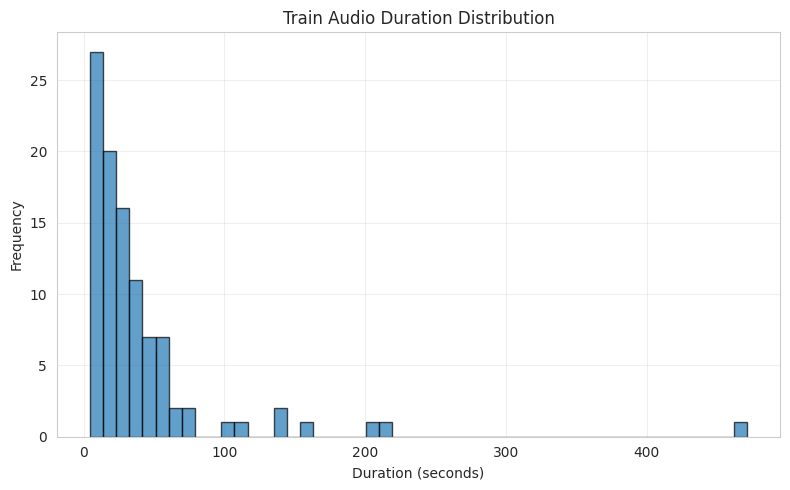

In [35]:
plt.figure(figsize=(8, 5))
plt.hist(audio_props_df['duration_seconds'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.title('Train Audio Duration Distribution')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2. Soundscape Duration Distribution

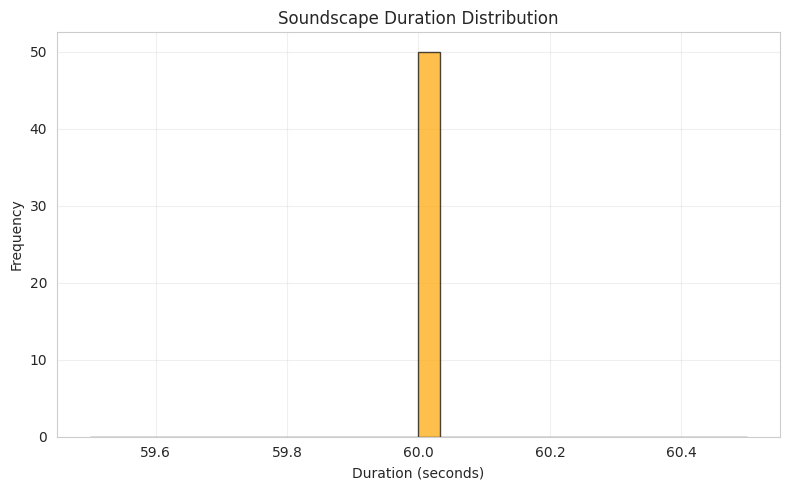

In [36]:
plt.figure(figsize=(8, 5))
plt.hist(soundscape_props_df['duration_seconds'], bins=30, edgecolor='black', alpha=0.7, color='orange')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.title('Soundscape Duration Distribution')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3. Sample Rate Distribution

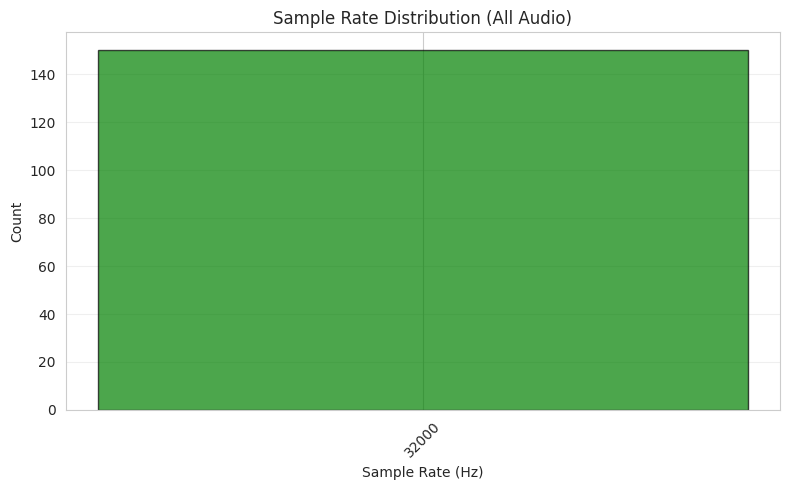

In [37]:
plt.figure(figsize=(8, 5))
sr_counts = pd.concat([
    audio_props_df['sample_rate'].value_counts(),
    soundscape_props_df['sample_rate'].value_counts()
], axis=1).fillna(0).sum(axis=1)
plt.bar(sr_counts.index.astype(str), sr_counts.values, edgecolor='black', alpha=0.7, color='green')
plt.xlabel('Sample Rate (Hz)')
plt.ylabel('Count')
plt.title('Sample Rate Distribution (All Audio)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 4. Distribution of Audio Files per Species

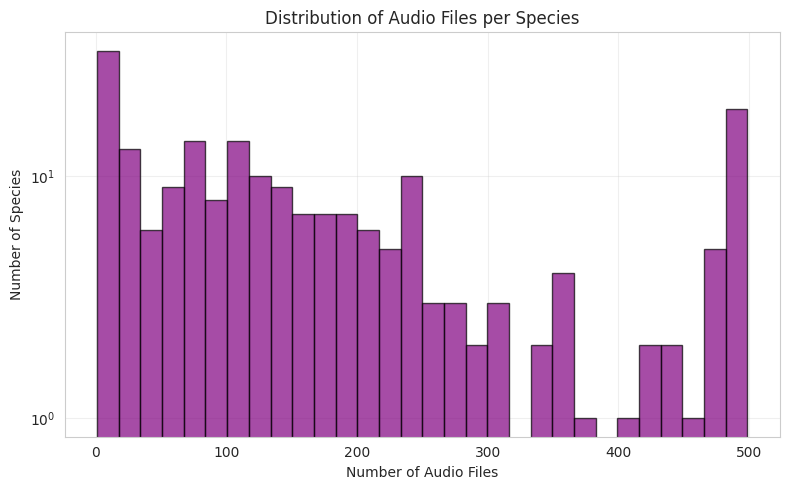

Visualization complete!


In [38]:
plt.figure(figsize=(8, 5))
plt.hist(list(species_audio_count.values()), bins=30, edgecolor='black', alpha=0.7, color='purple')
plt.xlabel('Number of Audio Files')
plt.ylabel('Number of Species')
plt.title('Distribution of Audio Files per Species')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualization complete!")

# Section D: Label Imbalance & Multi-label Analysis

### 1. Label Imbalance Analysis

In [39]:
# Train data imbalance
train_label_counts = train_df['primary_label'].value_counts()
print(f"\nTrain set (primary_label) statistics:")
print(f"  - Total unique labels: {len(train_label_counts)}")
print(f"  - Max count: {train_label_counts.max()}")
print(f"  - Min count: {train_label_counts.min()}")
print(f"  - Median: {train_label_counts.median():.1f}")
print(f"  - Mean: {train_label_counts.mean():.1f}")

# Imbalance ratio
imbalance_ratio = train_label_counts.max() / train_label_counts.min()
print(f"\n  Imbalance ratio (max/min): {imbalance_ratio:.1f}x")

# Long-tail analysis
sorted_counts = train_label_counts.sort_values(ascending=False)
cumsum_pct = (sorted_counts.cumsum() / sorted_counts.sum() * 100).values

# Find head, tail, body cutoffs (approximately 80-20 rule)
head_idx = np.where(cumsum_pct >= 80)[0][0]
print(f"\n  Top {head_idx} species comprise 80% of training data (head)")
print(f"  Remaining {len(sorted_counts) - head_idx} species comprise 20% (tail)")


Train set (primary_label) statistics:
  - Total unique labels: 206
  - Max count: 499
  - Min count: 1
  - Median: 125.0
  - Mean: 172.6

  Imbalance ratio (max/min): 499.0x

  Top 90 species comprise 80% of training data (head)
  Remaining 116 species comprise 20% (tail)


### 2. Multi-Label Soundscape Analysis

In [40]:
if 'num_species' in train_soundscapes_labels_df.columns:
    print(f"\nSegments by number of species:")
    multi_label_dist = train_soundscapes_labels_df['num_species'].value_counts().sort_index()
    print(multi_label_dist.to_string())
    
    pct_multi = (train_soundscapes_labels_df['num_species'] > 1).sum() / len(train_soundscapes_labels_df) * 100
    print(f"\nMulti-label segments: {pct_multi:.1f}% of all soundscape annotations")
elif 'num_labels' in train_soundscapes_labels_df.columns:
    print(f"\nSegments by number of labels:")
    multi_label_dist = train_soundscapes_labels_df['num_labels'].value_counts().sort_index()
    print(multi_label_dist.to_string())
    
    pct_multi = (train_soundscapes_labels_df['num_labels'] > 1).sum() / len(train_soundscapes_labels_df) * 100
    print(f"\nMulti-label segments: {pct_multi:.1f}% of all soundscape annotations")
else:
    print("\nCould not find 'num_species' or 'num_labels' in train_soundscapes_labels_df.")


Segments by number of labels:
num_labels
1     156
2      98
3     200
4     364
5     320
6     190
7     114
8      28
9       6
10      2

Multi-label segments: 89.4% of all soundscape annotations


### 3. Taxonomy Analysis

In [41]:
print(f"\nTaxonomy file statistics:")
print(f"  - Total species in taxonomy: {len(taxonomy_df)}")
print(f"  - Taxonomic classes: {taxonomy_df['class_name'].unique().tolist() if 'class_name' in taxonomy_df.columns else taxonomy_df['class'].unique().tolist()}")

if 'order' in taxonomy_df.columns:
    print(f"  - Taxonomic orders: {taxonomy_df['order'].nunique()}")

# Which taxonomy species are in training?
if 'primary_label' in train_df.columns and len(taxonomy_df) > 0:
    train_labels = set(train_df['primary_label'].unique())
    if 'primary_label' in taxonomy_df.columns:
        taxonomy_species = set(taxonomy_df['primary_label'].unique())
        coverage = len(train_labels & taxonomy_species) / len(taxonomy_species) * 100 if taxonomy_species else 0
        print(f"\n  - Species coverage: {coverage:.1f}% of taxonomy species have training data")


Taxonomy file statistics:
  - Total species in taxonomy: 234
  - Taxonomic classes: ['Insecta', 'Reptilia', 'Amphibia', 'Mammalia', 'Aves']

  - Species coverage: 88.0% of taxonomy species have training data


# Section E: Sample Audio & Spectrogram Visualization

### 1. Define Spectrogram Generation Function

In [42]:
# Function to create mel spectrogram
def create_mel_spectrogram(audio_path, sr=32000, n_mels=128, n_fft=512, hop_length=160, vmin=-80, vmax=0):
    """
    Load audio and create mel spectrogram.
    """
    try:
        # Load audio
        y, sr_loaded = librosa.load(str(audio_path), sr=sr, mono=True)
        
        # Create mel spectrogram
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
        S_db = librosa.power_to_db(S, ref=np.max)
        
        return y, sr, S_db
    except Exception as e:
        print(f"Error loading {audio_path}: {e}")
        return None, None, None

### 2. Select Diverse Audio Samples

In [43]:
# Select diverse sample audio files
print("Selecting diverse samples for visualization...")
sample_files = []

# Get examples from different species (top species)
top_species_list = train_df['primary_label'].value_counts().head(6).index.tolist()

for species in top_species_list:
    # Find audio files for this species
    species_audio = list((TRAIN_AUDIO_DIR / species).glob("*.ogg")) if (TRAIN_AUDIO_DIR / species).exists() else []
    if species_audio:
        sample_files.append((species, np.random.choice(species_audio)))

print(f"Selected {len(sample_files)} files for visualization.")

Selecting diverse samples for visualization...
Selected 6 files for visualization.


### 3. Generate and Display Spectrograms


Processing rubthr1: XC293345.ogg


/home/legionlinux/miniconda3/envs/torchenv/lib/python3.10/site-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)



Processing banana: iNat1375832.ogg

Processing fepowl: XC378359.ogg

Processing soulap1: XC421164.ogg

Processing houspa: XC122553.ogg

Processing coffal1: XC834087.ogg


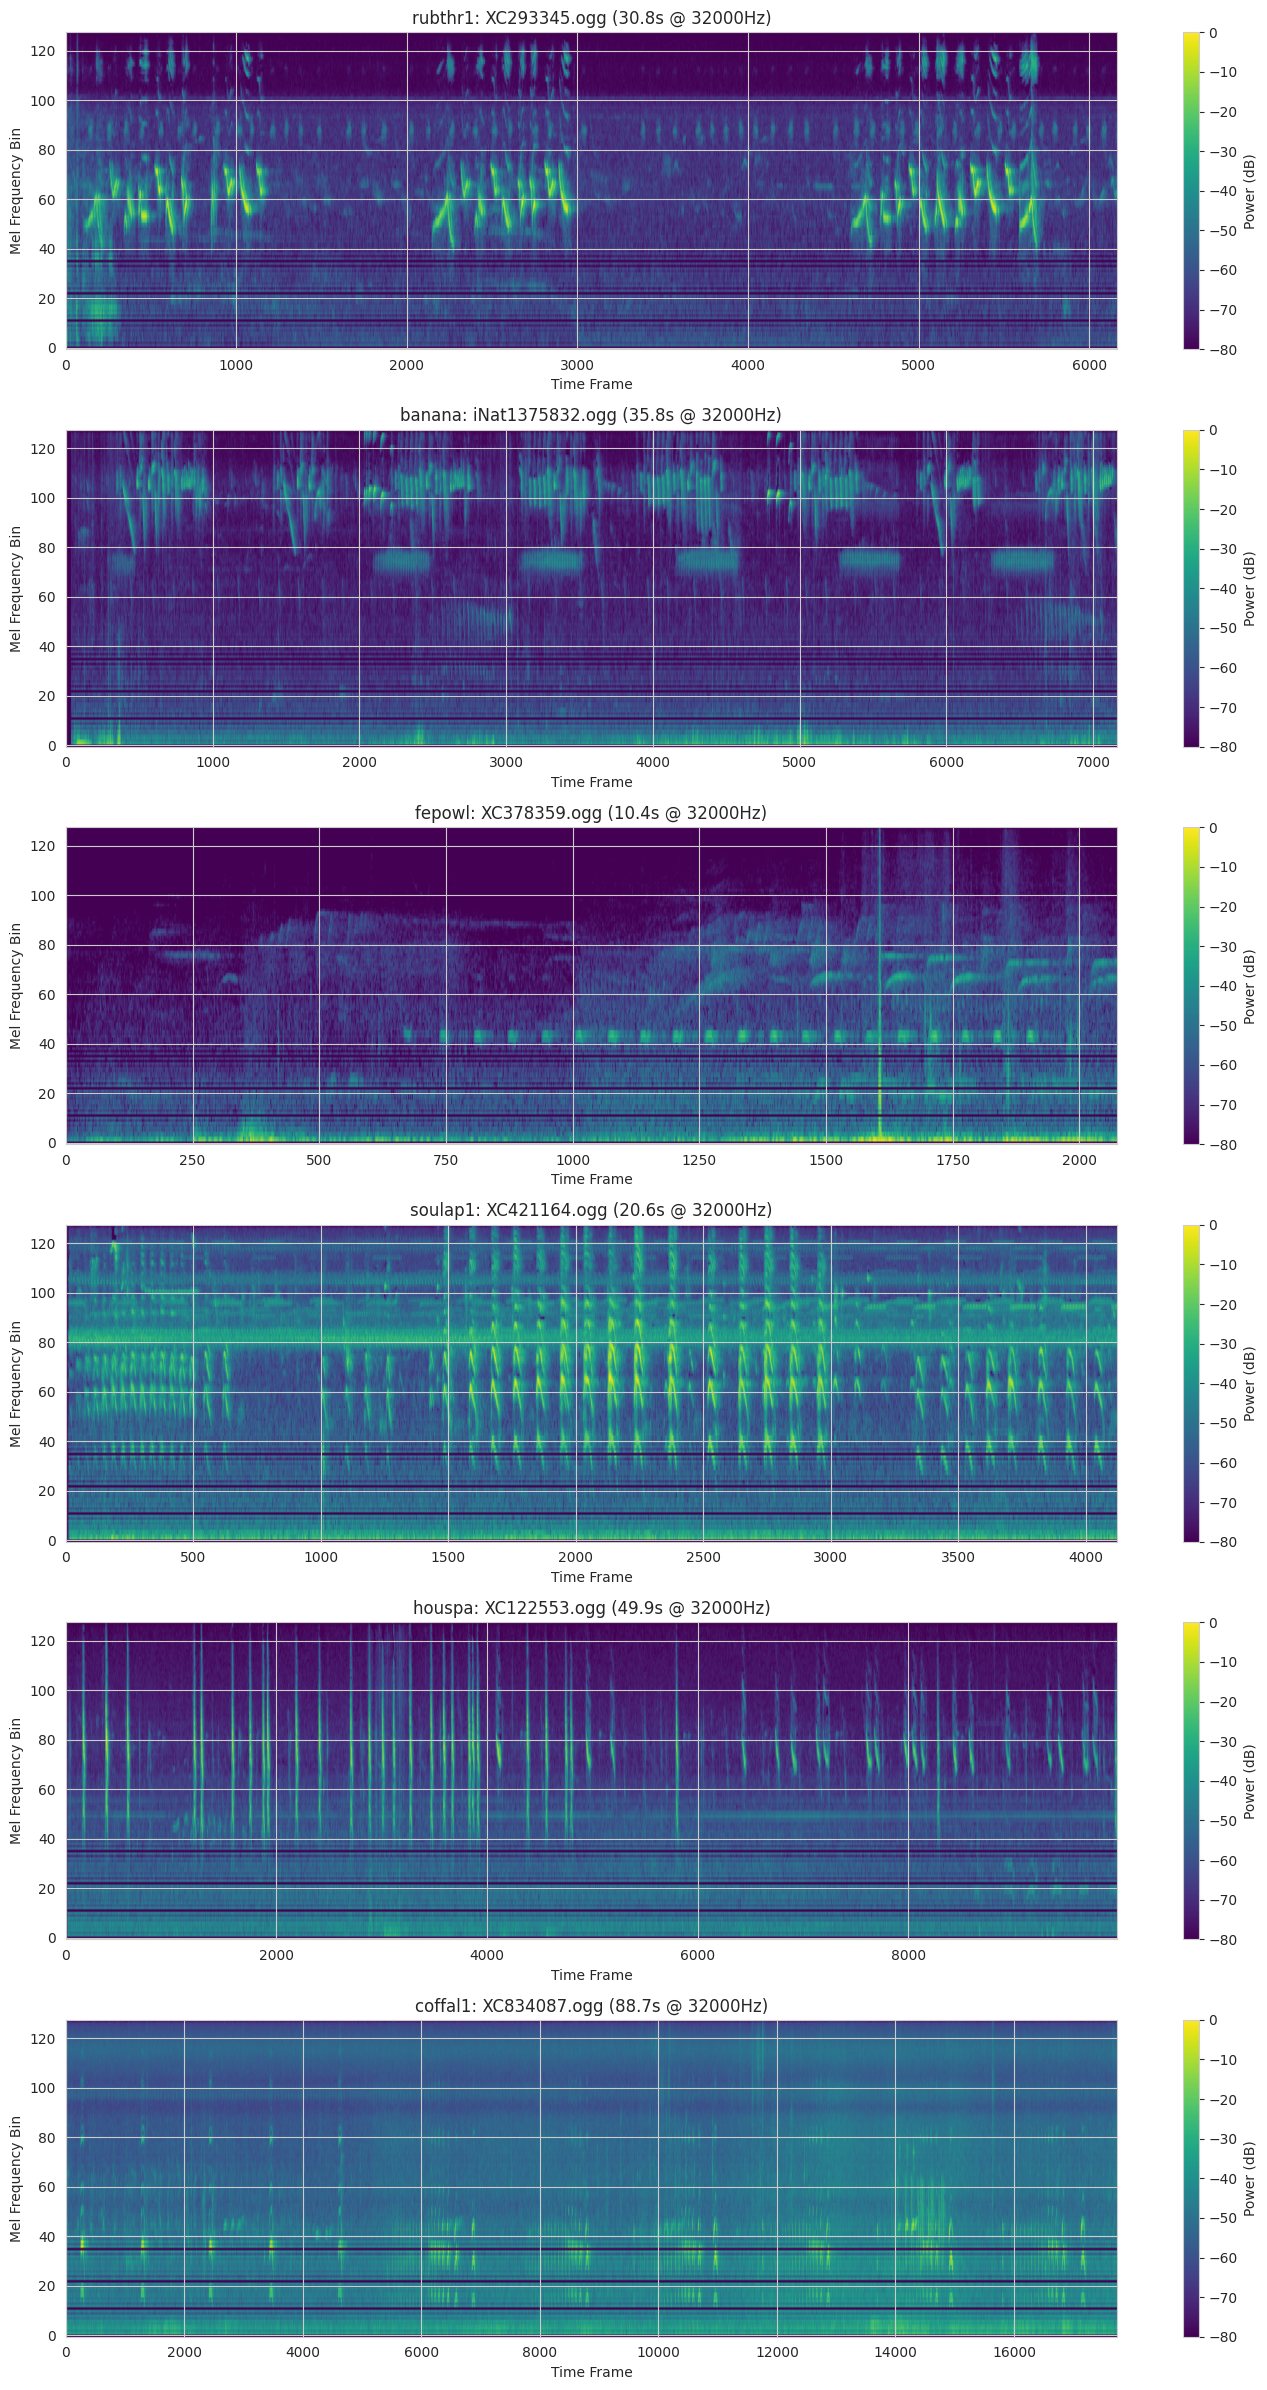


Spectrogram visualization complete!


In [44]:
# Create spectrograms visualization
if len(sample_files) > 0:
    fig, axes = plt.subplots(len(sample_files), 1, figsize=(14, 4 * len(sample_files)))
    if len(sample_files) == 1:
        axes = [axes]

    for idx, (species, audio_path) in enumerate(sample_files):
        print(f"\nProcessing {species}: {audio_path.name}")
        
        y, sr, S_db = create_mel_spectrogram(audio_path)
        
        if S_db is not None:
            # Create time and frequency axis
            img = axes[idx].imshow(S_db, aspect='auto', origin='lower', cmap='viridis', vmin=-80, vmax=0)
            axes[idx].set_ylabel('Mel Frequency Bin')
            axes[idx].set_xlabel('Time Frame')
            axes[idx].set_title(f'{species}: {audio_path.name} ({len(y)/sr:.1f}s @ {sr}Hz)')
            
            # Add colorbar
            cbar = plt.colorbar(img, ax=axes[idx])
            cbar.set_label('Power (dB)')

    plt.tight_layout()
    plt.show()

    print("\nSpectrogram visualization complete!")
else:
    print("No sample files found to visualize.")